In [16]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from scipy.stats import sem
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import re

In [17]:
def parse_completed_tasks(row):
    try:
        task_data = json.loads(row["completedTasks"].replace("'", '"'))
        return len(task_data), len(task_data.keys())
    except:
        return 0, 0

def infer_condition(group):
    if "role" not in group.columns:
        return "pooled"
    has_roles = group["role"].notna().any()
    return "reciprocal" if has_roles else "pooled"

correct_answers = {
    "neighborhood_1": {
        1: 2,
        2: 60000,
        3: 10
    },
    "neighborhood_2": {
        1: 3,
        2: 54000,
        3: 29
    },
    "neighborhood_3": {
        1: 3,
        2: 83000,
        3: 26
    },
    "neighborhood_4": {
        1: 2,
        2: 75000,
        3: 18
    },
    "neighborhood_5": {
        1: 2,
        2: 54000,
        3: 16
    },
    "neighborhood_6": {
        1: 3,
        2: 66500,
        3: 30
    },
    "neighborhood_7": {
        1: 2,
        2: 139046,
        3: 28
    },
    "neighborhood_8": {
        1: 2,
        2: 115000,
        3: 28
    },
    "neighborhood_9": {
        1: 3,
        2: 187700,
        3: 36
    },
    "neighborhood_10": {
        1: 3,
        2: 125800,
        3: 31
    },
    "neighborhood_11": {
        1: 2,
        2: 108000,
        3: 17
    },
    "neighborhood_12": {
        1: 2,
        2: 90000,
        3: 15
    },
    "neighborhood_13": {
        1: 2,
        2: 120000,
        3: 2
    },
    "neighborhood_14": {
        1: 2,
        2: 200000,
        3: 32
    },
}

In [18]:
def preprocess(filepath):
    import pandas as pd
    import ast
    import hashlib

    def stable_team_id(playerset):
        players_sorted = sorted(playerset)
        joined = ",".join(players_sorted)
        return "team_" + hashlib.md5(joined.encode()).hexdigest()[:8]

    df = pd.read_csv(filepath)

    # ---- STEP 1: Parse all responses ----
    parsed_responses = []
    for _, row in df.iterrows():
        if pd.notna(row.get("responses")):
            try:
                parsed_responses.extend(ast.literal_eval(row["responses"]))
            except:
                continue
    
    responses_df = pd.DataFrame(parsed_responses)

    if "stage" not in responses_df.columns and "column" in responses_df.columns:
        responses_df["stage"] = responses_df["column"]

    # Remove duplicate (playerId, taskId, stage) responses -- happens sometimes when saving to database
    responses_df = responses_df.drop_duplicates(subset=["playerId", "taskId", "stage"])

    # ---- STEP 2: Assign team_id and team_size from ButtonCheck ----
    button_df = df[df["name"] == "ButtonCheck"].copy()
    button_df["activePlayersList"] = button_df["activePlayers"].apply(
        lambda s: set(ast.literal_eval(s)) if pd.notna(s) else set()
    )
    button_df["team_id"] = button_df["activePlayersList"].apply(stable_team_id)
    button_df["team_size"] = button_df["activePlayersList"].apply(len)

    player_to_team = {}
    for _, row in button_df.iterrows():
        for pid in row["activePlayersList"]:
            player_to_team[pid] = (row["team_id"], row["team_size"])

    # ---- STEP 3: Backfill missing team info ----
    player_groups = responses_df.groupby("taskId")["playerId"].apply(set)
    inferred_team_ids = {}
    for players in player_groups:
        known = [player_to_team[pid][0] for pid in players if pid in player_to_team]
        if known:
            canonical_team_id = max(set(known), key=known.count)
            for pid in players:
                if pid not in player_to_team:
                    inferred_team_ids[pid] = canonical_team_id

    def get_team_id(pid):
        if pid in player_to_team:
            return player_to_team[pid][0]
        elif pid in inferred_team_ids:
            return inferred_team_ids[pid]
        return "unknown_team"

    def get_team_size(pid):
        if pid in player_to_team:
            return player_to_team[pid][1]
        elif pid in inferred_team_ids:
            return button_df[button_df["team_id"] == inferred_team_ids[pid]]["team_size"].iloc[0]
        return None

    responses_df["team_id"] = responses_df["playerId"].apply(get_team_id)
    responses_df["team_size"] = responses_df["playerId"].apply(get_team_size)
    responses_df["stage"] = pd.to_numeric(responses_df["stage"], errors="coerce")

    # ---- STEP 4: Stage-based task completion ----
    stages_per_task = (
        responses_df.groupby(["team_id", "taskId"])["stage"]
        .apply(lambda s: set([1, 2, 3]).issubset(set(s)))
        .reset_index(name="completed")
    )
    tasks_completed_per_team = (
        stages_per_task.groupby("team_id")["completed"]
        .sum()
        .reset_index(name="num_tasks_completed")
    )

    # ---- STEP 5: Override using completedTasks ----
    override_entries = []
    for _, row in df.iterrows():
        if pd.notna(row.get("completedTasks")) and pd.notna(row.get("responses")):
            try:
                tasks_dict = ast.literal_eval(row["completedTasks"])
                resp_list = ast.literal_eval(row["responses"])
                if not resp_list:
                    continue
                example_pid = resp_list[0]["playerId"]
                team_id = get_team_id(example_pid)

                def is_completed(task_data):
                    if not isinstance(task_data, dict):
                        return False
                    if set(task_data.keys()) <= {"totalCount"}:
                        return True
                    return task_data.get("totalCount", 0) >= 3

                num_completed = sum(1 for task in tasks_dict.values() if is_completed(task))
                override_entries.append((team_id, num_completed))
            except:
                continue

    override_df = pd.DataFrame(override_entries, columns=["team_id", "num_completed_override"])
    override_df = override_df.groupby("team_id")["num_completed_override"].max().reset_index()

    tasks_completed_per_team = tasks_completed_per_team.merge(
        override_df, on="team_id", how="left"
    )
    tasks_completed_per_team["num_tasks_completed"] = tasks_completed_per_team[
        "num_completed_override"
    ].fillna(tasks_completed_per_team["num_tasks_completed"])
    tasks_completed_per_team.drop(columns=["num_completed_override"], inplace=True)

    # ---- STEP 6: Final merge ----
    team_size_map = responses_df[["team_id", "team_size"]].drop_duplicates()

    if "infer_condition" in globals():
        team_conditions = (
            responses_df.groupby("team_id")
            .apply(infer_condition)
            .reset_index(name="condition")
        )
    else:
        team_conditions = pd.DataFrame(columns=["team_id", "condition"])

    stages_per_team = (
        responses_df.groupby("team_id")["stage"]
        .count()
        .reset_index(name="num_stages_completed")
    )

    full_team_summary = (
        tasks_completed_per_team
        .merge(team_size_map, on="team_id")
        .merge(team_conditions, on="team_id", how="left")
        .merge(stages_per_team, on="team_id")
    )

    full_team_summary = full_team_summary.query("team_size > 2")
    valid_teams = set(full_team_summary["team_id"])
    responses_df = responses_df[responses_df["team_id"].isin(valid_teams)]

    return full_team_summary, responses_df


In [19]:
def plot_team_size_by_tasks_completed(full_team_summary, title):
    agg = (
        full_team_summary
        .groupby(["fault", "condition", "team_size"])["num_tasks_completed"]
        .agg(["mean", sem])
        .reset_index()
        .rename(columns={"mean": "avg_completed", "sem": "sem_completed"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(title, fontsize=14, weight="bold", y=1.02)
    
    palette = {"pooled": "#1f77b4", "reciprocal": "#ff7f0e"}
    
    for ax, fault_state in zip(axes, [0, 1]):
        sub_fault = agg[agg["fault"] == fault_state]
        for network, color in palette.items():
            sub = sub_fault[sub_fault["condition"] == network].sort_values("team_size")
            x = sub["team_size"].values
            y = sub["avg_completed"].values
            e = sub["sem_completed"].values
            
            ax.plot(x, y,
                    marker="o",
                    markersize=6,
                    linewidth=2,
                    label=network.capitalize(),
                    color=color)
            # shaded CI
            ax.fill_between(x, y - e, y + e,
                            alpha=0.2,
                            color=color,
                            linewidth=0)
        
        ax.set_title("Faults" if fault_state == 1 else "No Faults",
                     fontsize=12, weight="semibold")
        ax.set_xlabel("Team size (members)")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    axes[0].set_ylabel("Tasks completed")
    axes[0].set_ylim(0, full_team_summary["num_tasks_completed"].max() * 1.1)
    
    axes[1].legend_.remove() if axes[1].legend_ else None

    handles, labels = axes[0].get_legend_handles_labels()

    # create a single legend for the whole figure
    fig.legend(
        handles=handles,
        labels=labels,
        title="Network",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.0),
        ncol=2,
        frameon=False
    )
    
    plt.tight_layout()
    plt.show()

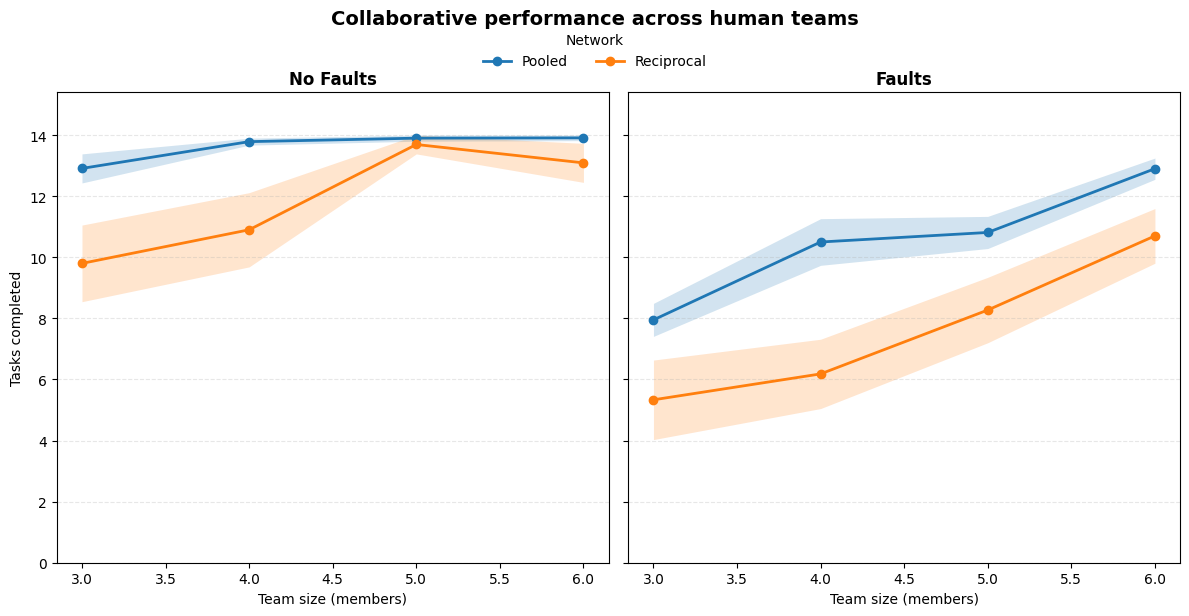

In [20]:
summary1, responses1 = preprocess("../data/Faults_1/stage.csv")
summary2, responses2 = preprocess("../data/Faults_2/stage.csv")
summary3, responses3 = preprocess("../data/Faults_3/stage.csv")
summary4, responses4 = preprocess("../data/Faults_4/stage.csv")

full_team_summary_1 = pd.concat([summary1, summary2], ignore_index=True)
full_team_summary_2 = pd.concat([full_team_summary_1, summary3], ignore_index=True)
full_team_summary = pd.concat([full_team_summary_2, summary4], ignore_index=True)

responses_df_1 = pd.concat([responses1, responses2], ignore_index=True)
responses_df_2 = pd.concat([responses_df_1, responses3], ignore_index=True)
responses_df = pd.concat([responses_df_2, responses4], ignore_index=True)

# Remove teams with a Prolific server error 
rows_to_remove = ["team_51029216", "team_ef47d7ae", "team_0fc5fe76"]
full_team_summary = full_team_summary[~full_team_summary["team_id"].isin(rows_to_remove)]
responses_df = responses_df[~responses_df["team_id"].isin(rows_to_remove)]

fault_summaries = []
for i in [1, 2, 3, 4]:
    summary, _ = preprocess(f"../data/Faults_{i}/stage.csv")
    summary["fault"] = 1           
    fault_summaries.append(summary)

nofault_summaries = []
for i in [1, 2]:
    summary, _ = preprocess(f"../data/NoFaults_{i}/stage.csv")
    summary["fault"] = 0           
    nofault_summaries.append(summary)

full_team_summary_all = pd.concat(
    fault_summaries + nofault_summaries,
    ignore_index=True
)

full_team_summary_all = full_team_summary_all[~full_team_summary_all["team_id"].isin(rows_to_remove)]

# Figure 2 (top panels): mean tasks completed by team size, structure, and fault condition
plot_team_size_by_tasks_completed(full_team_summary_all, "Collaborative performance across human teams")

In [21]:
summary1, responses1 = preprocess("../data/NoFaults_1/stage.csv")
summary2, responses2 = preprocess("../data/NoFaults_2/stage.csv")

full_team_summary_nofaults = pd.concat([summary1, summary2], ignore_index=True)
responses_df_nofaults = pd.concat([responses1, responses2], ignore_index=True)

In [22]:
def load_stimuli(path="../task_code/faults_condition/client/src/Stage.jsx"):
    """Read the neighborhoods participants saw (predefinedTasks in Stage.jsx)."""
    src = open(path).read()
    start = src.index("[", src.index("const predefinedTasks"))
    depth = 0
    for end, ch in enumerate(src[start:], start):
        depth += (ch == "[") - (ch == "]")
        if depth == 0:
            break
    js = src[start:end + 1]
    js = re.sub(r'"?(\w+)"?\s*:', r'"\1":', js)   # quote object keys
    js = re.sub(r",\s*([\]}])", r"\1", js)       # drop trailing commas
    return json.loads(js)

def compute_answers(task):
    houses = task["houses"]
    residents = [r for h in houses for r in h["residents"]]
    avg_people = len(residents) / len(houses)
    assert avg_people.is_integer(), f"{task['id']}: non-integer average ({avg_people})"
    return {
        1: int(avg_people),                                                   # avg people per household
        2: max(sum(r["income"] for r in h["residents"]) for h in houses),     # max household income
        3: sum(r["commuteDistance"] for r in residents if r["ageGroup"] == "child"),  # total children's commute
    }

stimuli = load_stimuli()
assert stimuli == load_stimuli("../task_code/no_faults_condition/client/src/Stage.jsx"), "stimuli differ across conditions"
correct_answers = {task["id"]: compute_answers(task) for task in stimuli}

def is_correct(row):
    task = row["taskId"]
    try:
        stage = int(row["stage"])
    except (TypeError, ValueError):
        stage = {"AVERAGE PEOPLE": 1,
                 "MAXIMUM INCOME": 2,
                 "CHILDREN'S COMMUTE DISTANCE": 3}[str(row["role"])]
    return int(row["response"]) == correct_answers[task][stage]

responses_df["is_correct"] = responses_df.apply(is_correct, axis=1)
responses_df_nofaults["is_correct"] = responses_df_nofaults.apply(is_correct, axis=1)

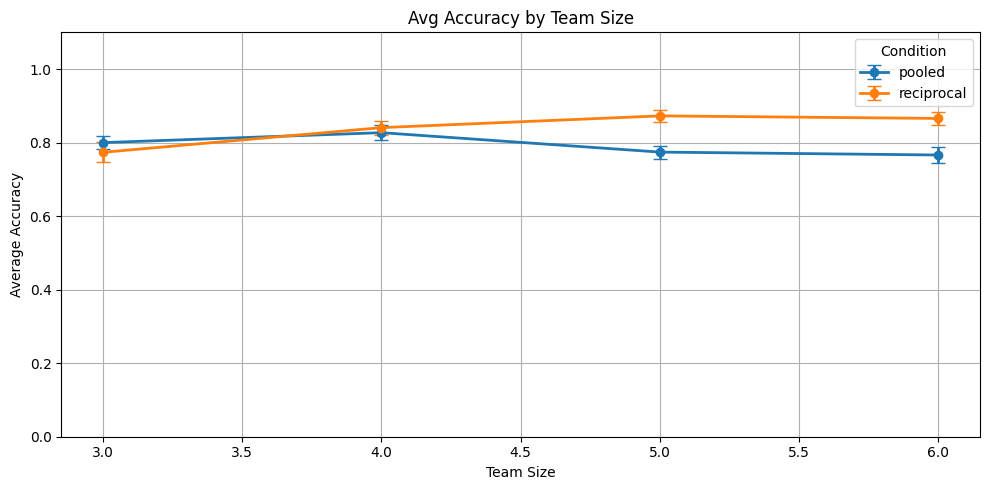

In [23]:
team_meta = full_team_summary.set_index("team_id")[["team_size", "condition"]]

valid_neighborhoods = responses_df["taskId"].dropna().unique()
filtered_responses = responses_df[responses_df["taskId"].isin(valid_neighborhoods)]

filtered_responses = filtered_responses.copy()
filtered_responses["team_size"] = filtered_responses["team_id"].map(team_meta["team_size"])
filtered_responses["condition"] = filtered_responses["team_id"].map(team_meta["condition"])

filtered_by_size_condition = (
    filtered_responses.dropna(subset=["is_correct", "team_size", "condition"])
    .groupby(["team_size", "condition"])["is_correct"]
    .agg(["mean", sem])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy", "sem": "sem_accuracy"})
)

# Figure B1: average task accuracy by team size and team structure (condition)
plt.figure(figsize=(10, 5))
for condition, group in filtered_by_size_condition.groupby("condition"):
    plt.errorbar(
        group["team_size"],
        group["avg_accuracy"],
        yerr=group["sem_accuracy"],
        label=condition,
        capsize=5,
        marker="o",
        linestyle="-",
        linewidth=2
    )
plt.title("Avg Accuracy by Team Size")
plt.xlabel("Team Size")
plt.ylabel("Average Accuracy")
plt.ylim(0, 1.1)
plt.legend(title="Condition")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
full_team_summary["fault"] = 1
full_team_summary_nofaults["fault"] = 0

df = pd.concat([full_team_summary, full_team_summary_nofaults], ignore_index=True)

df = df.rename(columns={
    "num_tasks_completed": "tasks",
    "team_size": "size",
    "condition": "network",
    "num_stages_completed": "stages"
})

df["task_rate"] = df["tasks"]

model = smf.ols("task_rate ~ C(fault) * size * C(network)", data=df).fit()
anova_table = anova_lm(model, typ=2)
print(anova_table)

                               sum_sq     df           F        PR(>F)
C(fault)                   666.644799    1.0  107.480873  5.060197e-20
C(network)                 240.686415    1.0   38.805052  3.253243e-09
C(fault):C(network)         14.398715    1.0    2.321456  1.293653e-01
size                       351.502909    1.0   56.671618  2.431898e-12
C(fault):size               49.492797    1.0    7.979555  5.267844e-03
size:C(network)             21.663351    1.0    3.492708  6.327333e-02
C(fault):size:C(network)     6.487942    1.0    1.046029  3.078037e-01
Residual                  1110.238652  179.0         NaN           NaN


In [25]:
ss_resid = anova_table.loc["Residual", "sum_sq"]
df_den = int(model.df_resid)

stats_table = anova_table.drop(index="Residual").copy()
stats_table["df_num"] = stats_table["df"].astype(int)
stats_table["df_den"] = df_den
stats_table["partial_eta_sq"] = stats_table["sum_sq"] / (stats_table["sum_sq"] + ss_resid)

term_labels = {
    "C(fault)": "Fault (main effect)",
    "size": "Team size (main effect)",
    "C(network)": "Team structure (main effect)",
    "C(fault):size": "Fault x Team size",
    "C(fault):C(network)": "Fault x Team structure",
    "size:C(network)": "Team size x Team structure",
    "C(fault):size:C(network)": "Fault x Team size x Team structure",
}

def apa_p(p):
    return "< .001" if p < .001 else f"= {p:.3f}"

print(f"{'Effect':<38}{'F':>8}{'df':>14}{'p':>10}{'partial eta^2':>16}")
print("-" * 86)
for term, label in term_labels.items():
    row = stats_table.loc[term]
    df_str = f"({int(row['df_num'])}, {int(row['df_den'])})"
    print(f"{label:<38}{row['F']:>8.2f}{df_str:>14}{apa_p(row['PR(>F)']):>10}{row['partial_eta_sq']:>16.3f}")

Effect                                       F            df         p   partial eta^2
--------------------------------------------------------------------------------------
Fault (main effect)                     107.48      (1, 179)    < .001           0.375
Team size (main effect)                  56.67      (1, 179)    < .001           0.240
Team structure (main effect)             38.81      (1, 179)    < .001           0.178
Fault x Team size                         7.98      (1, 179)   = 0.005           0.043
Fault x Team structure                    2.32      (1, 179)   = 0.129           0.013
Team size x Team structure                3.49      (1, 179)   = 0.063           0.019
Fault x Team size x Team structure        1.05      (1, 179)   = 0.308           0.006


In [ ]:
team_cols = ["team_id", "num_tasks_completed", "team_size", "condition",
             "num_stages_completed", "fault"]
team_summary_out = pd.concat(
    [full_team_summary[team_cols], full_team_summary_nofaults[team_cols]],
    ignore_index=True,
)
team_summary_out.to_csv("../data/exp1_team_summary.csv", index=False)

response_cols = ["playerId", "playerName", "taskId", "stage", "role", "column",
                 "response", "is_correct", "durationMs", "submittedAt",
                 "team_id", "team_size", "fault"]
responses_out = pd.concat(
    [responses_df.assign(fault=1), responses_df_nofaults.assign(fault=0)],
    ignore_index=True,
).reindex(columns=response_cols)
responses_out["stage"] = responses_out["stage"].fillna(responses_out["column"]).astype(int)
responses_out["is_correct"] = responses_out["is_correct"].astype(int)
responses_out.to_csv("../data/exp1_responses_long.csv", index=False)

print(f"Wrote {len(team_summary_out)} teams and {len(responses_out)} responses.")